# Chapter 12 — Generative Adversarial Networks for Tabular Data Synthesis

A **Generative Adversarial Network (GAN)** trains two neural networks in opposition:
- The **Generator** learns to produce synthetic records that resemble real data.
- The **Discriminator** learns to distinguish real records from generated ones.

Training alternates: the generator tries to fool the discriminator; the discriminator tries to catch the generator. At convergence, the generator produces data indistinguishable from the real dataset.

**When to use this approach:**
- A full real dataset is available but cannot be shared (confidentiality, privacy regulations).
- The data has complex non-linear relationships that parametric methods (Cholesky, Copula) cannot capture.
- Sufficient compute is available for training (GANs are more expensive than analytic methods).

> **Data:** This notebook reads `../../data/sim_data_vasko - rab - sim_data.csv` — a Bulgarian financial and demographic survey dataset (~15 000 records, ~48 features).  
> **Pre-trained models:** The trained generator and discriminator are saved in `../../models/`. Skip to the *Load and Generate* section to use them without retraining.

## 1. Load and Preprocess Data

Categorical variables are label-encoded; all features are scaled to [0, 1] with MinMaxScaler so the generator output is bounded.

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('../../data/sim_data_vasko - rab - sim_data.csv')

In [4]:
data = data[data['total'] != 0]

In [5]:
data.columns


Index(['ind', 'sex', 'age_sim', 'lv_educ', 'empl_stat', 'marit_stat',
       'house_memb', 'chil_u_18_y', 'nation', 'religion', 'soc_econ_stat',
       'prof_ind', 'prof_stat', 'count_house', 'own_field', 'num_car_house',
       'own_rent_house', 'edu', 'temperam', 'ind_risk_sim', 'invest_exp_sim',
       'shares', 'corp_oblig', 'oth', 'inv_fund', 'cash', 'crypto', 'gov_bond',
       'deposits', 'income_sim', 'pers_exp_sim', 'house_exp_sim', 'taxes_sim',
       'transp_telecom_sim', 'hobby_sim', 'banking', 'bk_oprat', 'bk_dc',
       'bk_cc', 'bk_acc', 'ins_prop', 'ins_life', 'ins_casco', 'health_ins',
       'overdraft', 'cons_cred', 'mortgage', 'car_leas', 'pens_ins', '.',
       'lv_educ.1', 'empl_stat.1', 'marit_stat.1', 'house_memb.1',
       'chil_u_18_y.1', 'nation.1', 'religion.1', 'soc_econ_stat.1',
       'prof_ind.1', 'prof_stat.1', 'count_house.1', 'own_field.1',
       'num_car_house.1', 'own_rent_house.1', 'edu.1', 'temperam.1',
       'ind_risk_sim.1', 'invest_exp_sim.1'

In [6]:
data = data.drop(['.',
       'lv_educ.1', 'empl_stat.1', 'marit_stat.1', 'house_memb.1',
       'chil_u_18_y.1', 'nation.1', 'religion.1', 'soc_econ_stat.1',
       'prof_ind.1', 'prof_stat.1', 'count_house.1', 'own_field.1',
       'num_car_house.1', 'own_rent_house.1', 'edu.1', 'temperam.1',
       'ind_risk_sim.1', 'invest_exp_sim.1', 'shares.1', 'corp_oblig.1',
       'oth.1', 'inv_fund.1', 'cash.1', 'crypto.1', 'gov_bond.1', 'deposits.1',
       'income_sim.1', 'pers_exp_sim.1', 'house_exp_sim.1', 'taxes_sim.1',
       'transp_telecom_sim.1', 'hobby_sim.1', 'banking.1', 'bk_oprat.1',
       'bk_dc.1', 'bk_cc.1', 'bk_acc.1', 'ins_prop.1', 'ins_life.1',
       'ins_casco.1', 'health_ins.1', 'overdraft.1', 'cons_cred.1',
       'mortgage.1', 'car_leas.1', 'pens_ins.1','total','Unnamed: 96','ind']
, axis=1)

In [7]:
# List of columns that are NOT supposed to be integers
non_integer_columns = ['ind_risk_sim']  # list column names

In [8]:
#label_encoders = {}
#for column in data.columns:
#    if data[column].dtype == 'object':  # For categorical columns
#        le = LabelEncoder()
#        data[column] = le.fit_transform(data[column])
#        label_encoders[column] = le

In [9]:
# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler to your data and transform it
scaled_data = scaler.fit_transform(data)

# Save the minimum and maximum values
min_values = scaler.data_min_
max_values = scaler.data_max_

# Convert the scaled data back to a DataFrame (optional)
# This step is useful if you want to keep the DataFrame format
scaled_data = pd.DataFrame(scaled_data, columns=data.columns)

## 2. Build the GAN Architecture

Both generator and discriminator are fully-connected networks. The generator maps a random noise vector (seed) to the feature space; the discriminator outputs a binary real/fake probability.

In [10]:
scaled_data.head()

,sex,age_sim,lv_educ,empl_stat,marit_stat,house_memb,chil_u_18_y,nation,religion,soc_econ_stat,...,bk_acc,ins_prop,ins_life,ins_casco,health_ins,overdraft,cons_cred,mortgage,car_leas,pens_ins
0,1.0,0.549020,0.5,0.75,0.666667,0.166667,0.000000,0.0,0.333333,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.823529,0.0,0.50,1.000000,0.500000,0.000000,0.0,0.333333,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.313725,0.5,0.50,0.333333,0.500000,0.000000,0.0,0.333333,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.588235,0.0,0.75,0.333333,0.500000,0.000000,0.0,0.500000,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.313725,0.5,0.50,1.000000,1.000000,0.666667,0.0,0.333333,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
def build_generator(seed_size, features):
    model = tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=seed_size),
        layers.Dense(256, activation='relu'),
        layers.Dense(features, activation='linear')  # Output layer with one neuron per feature
    ])
    return model

In [12]:
def build_discriminator(features):
    model = tf.keras.Sequential([
        layers.Dense(256, activation='relu', input_dim=features),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')  # Binary classification output
    ])
    return model

In [13]:
def compile_gan(generator, discriminator, seed_size):
    # Discriminator model that labels real data as 1 and fake data as 0
    discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Combined model
    discriminator.trainable = False  # Freeze the discriminator when training the generator
    gan_input = tf.keras.Input(shape=(seed_size,))
    gan_output = discriminator(generator(gan_input))
    gan = tf.keras.Model(gan_input, gan_output)
    # Compile the combined model
    # Optionally, you can add a metric if it makes sense for your generator evaluation
    gan.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # Example if you decide to track accuracy
    
    return gan


## 3. Train the GAN

Training alternates between updating the discriminator (on real + fake batches) and updating the generator (via the combined GAN model with frozen discriminator weights). Loss and accuracy are tracked per epoch.

In [14]:
def train_gan(generator, discriminator, gan, dataset, seed_size, epochs=1000, batch_size=32):
    generator_losses = []
    generator_accuracies = []  # Assuming you have some metric like accuracy for generator
    discriminator_losses = []
    discriminator_accuracies = []
    
    for epoch in range(epochs):
        # Train Discriminator with real data
        idx = np.random.randint(0, dataset.shape[0], batch_size)
        real_data = dataset.iloc[idx]
        real_labels = np.ones((batch_size, 1))
        d_loss_real, d_acc_real = discriminator.train_on_batch(real_data, real_labels)
        
        # Train Discriminator with fake data
        noise = np.random.normal(0, 1, size=(batch_size, seed_size))
        fake_data = generator.predict(noise)
        fake_labels = np.zeros((batch_size, 1))
        d_loss_fake, d_acc_fake = discriminator.train_on_batch(fake_data, fake_labels)
        
        # Average discriminator loss and accuracy
        d_loss = 0.5 * (d_loss_real + d_loss_fake)
        d_acc = 0.5 * (d_acc_real + d_acc_fake)
        
        # Train Generator
        misleading_targets = np.ones((batch_size, 1))
        g_loss, g_acc = gan.train_on_batch(noise, misleading_targets)  # This assumes your GAN also reports accuracy
        
        # Save the metrics
        generator_losses.append(g_loss)
        generator_accuracies.append(g_acc)
        discriminator_losses.append(d_loss)
        discriminator_accuracies.append(d_acc)
        
        if epoch % 100 == 0:
            print(f"Epoch: {epoch} \t Discriminator Loss/Accuracy: {d_loss}/{d_acc} \t Generator Loss/Accuracy: {g_loss}/{g_acc}")
    
    return generator_losses, generator_accuracies, discriminator_losses, discriminator_accuracies



In [15]:
# Define seed size
seed_size = 100  # This is an arbitrary choice; you may need to adjust it
epochs = 10000
# Define the number of features (equal to the number of columns in your scaled dataset)
features = scaled_data.shape[1]

# Build the generator and discriminator
generator = build_generator(seed_size, features)
discriminator = build_discriminator(features)

# Compile the GAN
gan = compile_gan(generator, discriminator, seed_size)

2024-06-27 22:03:29.070763: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2024-06-27 22:03:29.070782: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2024-06-27 22:03:29.070797: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (junior-TravelMate-P214-53): /proc/driver/nvidia/version does not exist
2024-06-27 22:03:29.071003: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [48]:
# Start the training process
# Note: The training data (scaled_data.values) should be a NumPy array for compatibility with Keras/TensorFlow operations
gen_losses, gen_accs, disc_losses, disc_accs = train_gan(
    generator, 
    discriminator, 
    gan, 
    scaled_data, 
    seed_size, 
    epochs, 
    batch_size=32
)

1/1 [==============================] - 0s 33ms/step
Epoch: 0 	 Discriminator Loss/Accuracy: 0.7973385751247406/0.21875 	 Generator Loss/Accuracy: 0.6953590512275696/0.46875
1/1 [==============================] - 0s 14ms/step
Epoch: 100 	 Discriminator Loss/Accuracy: 0.16804102063179016/0.9375 	 Generator Loss/Accuracy: 5.720197677612305/0.0
1/1 [==============================] - 0s 13ms/step


1/1 [==============================] - 0s 16ms/step
Epoch: 200 	 Discriminator Loss/Accuracy: 0.5737679302692413/0.75 	 Generator Loss/Accuracy: 2.3898143768310547/0.0625
1/1 [==============================] - 0s 14ms/step
Epoch: 300 	 Discriminator Loss/Accuracy: 0.4515104219317436/0.828125 	 Generator Loss/Accuracy: 2.0707249641418457/0.0625
1/1 [==============================] - 0s 18ms/step


1/1 [==============================] - 0s 13ms/step
Epoch: 400 	 Discriminator Loss/Accuracy: 0.2326248735189438/0.96875 	 Generator Loss/Accuracy: 1.6319226026535034/0.0
1/1 [==============================] - 0s 12ms/step
Epoch: 500 	 Discriminator Loss/Accuracy: 0.18197983503341675/0.953125 	 Generator Loss/Accuracy: 3.039363384246826/0.03125
1/1 [==============================] - 0s 14ms/step
Epoch: 600 	 Discriminator Loss/Accuracy: 0.21963047236204147/0.9375 	 Generator Loss/Accuracy: 3.0475950241088867/0.0
1/1 [==============================] - 0s 14ms/step


1/1 [==============================] - 0s 15ms/step
Epoch: 700 	 Discriminator Loss/Accuracy: 0.19986164942383766/0.953125 	 Generator Loss/Accuracy: 2.760093927383423/0.0
1/1 [==============================] - 0s 13ms/step
Epoch: 800 	 Discriminator Loss/Accuracy: 0.13642097264528275/0.953125 	 Generator Loss/Accuracy: 4.151896953582764/0.0
1/1 [==============================] - 0s 14ms/step
Epoch: 900 	 Discriminator Loss/Accuracy: 0.21470202505588531/0.890625 	 Generator Loss/Accuracy: 4.1997199058532715/0.0625
1/1 [==============================] - 0s 16ms/step


1/1 [==============================] - 0s 14ms/step
Epoch: 1000 	 Discriminator Loss/Accuracy: 0.09941921755671501/0.984375 	 Generator Loss/Accuracy: 3.256967306137085/0.0
1/1 [==============================] - 0s 13ms/step
Epoch: 1100 	 Discriminator Loss/Accuracy: 0.21206524968147278/0.890625 	 Generator Loss/Accuracy: 3.056894302368164/0.0
1/1 [==============================] - 0s 13ms/step
Epoch: 1200 	 Discriminator Loss/Accuracy: 0.18232989311218262/0.90625 	 Generator Loss/Accuracy: 4.651701927185059/0.03125
1/1 [==============================] - 0s 13ms/step


...

1/1 [==============================] - 0s 14ms/step
Epoch: 8800 	 Discriminator Loss/Accuracy: 0.03405267745256424/1.0 	 Generator Loss/Accuracy: 4.699529647827148/0.03125
1/1 [==============================] - 0s 12ms/step
Epoch: 8900 	 Discriminator Loss/Accuracy: 0.05728895962238312/0.984375 	 Generator Loss/Accuracy: 4.638837814331055/0.0
1/1 [==============================] - 0s 13ms/step


1/1 [==============================] - 0s 12ms/step
Epoch: 9000 	 Discriminator Loss/Accuracy: 0.1458173543214798/0.953125 	 Generator Loss/Accuracy: 3.816270351409912/0.0
1/1 [==============================] - 0s 13ms/step
Epoch: 9100 	 Discriminator Loss/Accuracy: 0.031915657222270966/1.0 	 Generator Loss/Accuracy: 5.575894355773926/0.03125
1/1 [==============================] - 0s 13ms/step
Epoch: 9200 	 Discriminator Loss/Accuracy: 0.09360670670866966/0.984375 	 Generator Loss/Accuracy: 4.241753101348877/0.03125
1/1 [==============================] - 0s 13ms/step


1/1 [==============================] - 0s 16ms/step
Epoch: 9300 	 Discriminator Loss/Accuracy: 0.09471123665571213/0.953125 	 Generator Loss/Accuracy: 4.291386604309082/0.03125
1/1 [==============================] - 0s 13ms/step
Epoch: 9400 	 Discriminator Loss/Accuracy: 0.12942424416542053/0.953125 	 Generator Loss/Accuracy: 5.062787055969238/0.03125
1/1 [==============================] - 0s 12ms/step
Epoch: 9500 	 Discriminator Loss/Accuracy: 0.12291527539491653/0.9375 	 Generator Loss/Accuracy: 5.166433334350586/0.0625
1/1 [==============================] - 0s 13ms/step


1/1 [==============================] - 0s 14ms/step
Epoch: 9600 	 Discriminator Loss/Accuracy: 0.3072754889726639/0.859375 	 Generator Loss/Accuracy: 4.123762130737305/0.09375
1/1 [==============================] - 0s 13ms/step
Epoch: 9700 	 Discriminator Loss/Accuracy: 0.08159801736474037/0.984375 	 Generator Loss/Accuracy: 4.6115312576293945/0.0
1/1 [==============================] - 0s 13ms/step
Epoch: 9800 	 Discriminator Loss/Accuracy: 0.03342241141945124/0.984375 	 Generator Loss/Accuracy: 5.689058303833008/0.0
1/1 [==============================] - 0s 13ms/step


1/1 [==============================] - 0s 12ms/step
Epoch: 9900 	 Discriminator Loss/Accuracy: 0.06762462854385376/0.953125 	 Generator Loss/Accuracy: 5.188799858093262/0.03125
1/1 [==============================] - 0s 12ms/step


## 4. Save Pre-trained Models

In [49]:
# Save the models in the recommended Keras format
generator.save('../../models/generator.tf')  # Use '.tf' or '.keras' extension
discriminator.save('../../models/discriminator.tf')

## 5. Load Pre-trained Models and Generate Data

The saved models can be loaded without retraining. We generate a synthetic dataset and inverse-scale it back to the original feature ranges.

In [57]:
import matplotlib.pyplot as plt

def plot_training_metrics(generator_losses, generator_accuracies, discriminator_losses, discriminator_accuracies):
    epochs = range(len(generator_losses))

    # Plot for losses
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, generator_losses, label='Generator Loss')
    plt.plot(epochs, discriminator_losses, label='Discriminator Loss')
    plt.title('Training Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot for accuracies
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, generator_accuracies, label='Generator Accuracy')
    plt.plot(epochs, discriminator_accuracies, label='Discriminator Accuracy')
    plt.title('Training Accuracies')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

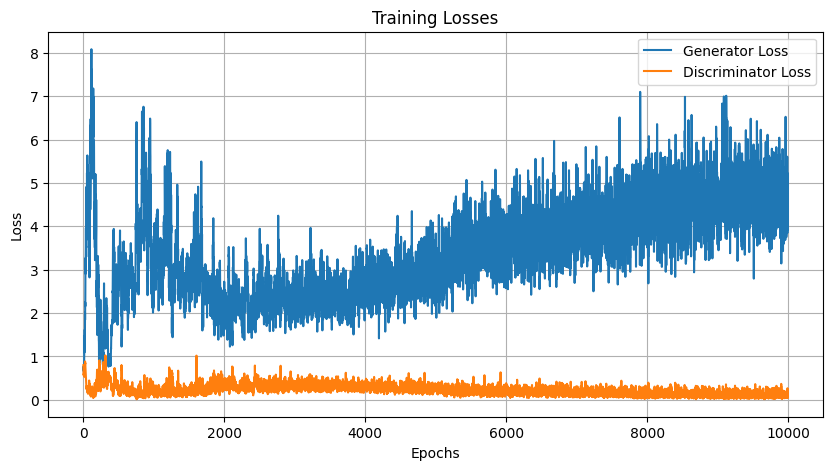

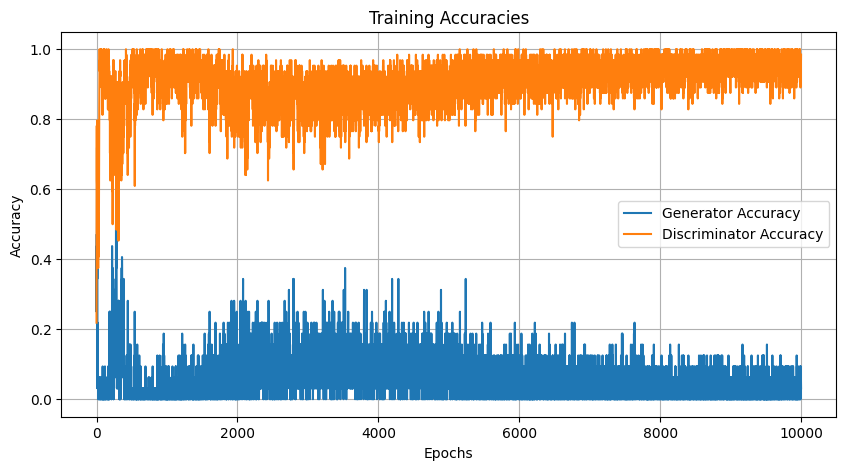

In [58]:
plot_training_metrics(gen_losses, gen_accs, disc_losses, disc_accs)

In [79]:
# Load the models without their compile configurations
generator = load_model('../../models/generator.tf')
discriminator = load_model('../../models/discriminator.tf')

In [80]:
# Manually compile the discriminator for further training or evaluation
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [81]:
def generate_valid_data(generator, seed_size, num_samples, real_data_min, real_data_max, tolerance=0.05):
    # Apply tolerance
    min_bounds = real_data_min - (np.abs(real_data_min) * tolerance)
    max_bounds = real_data_max + (np.abs(real_data_max) * tolerance)

    valid_generated_data = np.empty((0, real_data_min.size))
    while valid_generated_data.shape[0] < num_samples:
        remaining_samples = num_samples - valid_generated_data.shape[0]
        random_noise = np.random.normal(0, 1, size=(remaining_samples, seed_size))
        new_generated_data = generator.predict(random_noise)

        valid_mask = np.all((new_generated_data >= min_bounds) & (new_generated_data <= max_bounds), axis=1)
        valid_data = new_generated_data[valid_mask]
        valid_generated_data = np.vstack([valid_generated_data, valid_data])

        print(f"Generated {new_generated_data.shape[0]} records, accepted {valid_data.shape[0]} records.")

    return valid_generated_data[:num_samples]


In [82]:
# Usage of the function:
# Define min and max from real data (could be calculated or predefined)
#tolerance = 0.5  # 10% tolerance
#real_data_min = min_values *(1 - tolerance)
#real_data_max = max_values *(1 - tolerance)


# Define the number of samples to generate and the seed size
#num_samples = 15000
#seed_size = 100  # This should match the input size of your generator

# Assuming 'generator' is already trained and available
#generated_data = generate_valid_data(generator, seed_size, num_samples, real_data_min, real_data_max)



### Generate Random Noise

# Define the number of samples you want to generate
num_samples = 15000

# Define the dimensionality of the random noise (seed size)
seed_size = 100  # This should match the input size of your generator

# Generate random noise as input for the generator
random_noise = np.random.normal(0, 1, size=(num_samples, seed_size))

### Use the Generator to Create New Data

# Assuming `generator` is your loaded or trained generator model
generated_data = generator.predict(random_noise)

469/469 [==============================] - 1s 821us/step


In [83]:
generated_data

array([[ 1.0889997e+00,  4.7297961e-01,  5.5284810e-01, ...,
        -1.7361468e-02,  1.7968878e-02, -2.6732127e-03],
       [ 1.0918653e+00,  6.6839194e-01,  2.9421818e-01, ...,
        -1.9262807e-02,  9.7723037e-01,  4.7735147e-02],
       [ 1.0286255e+00,  7.2937638e-01, -7.6515287e-02, ...,
         8.7512545e-03,  2.1199076e-02, -1.6228032e-03],
       ...,
       [ 1.1749427e+00,  1.3298886e+00,  1.6320744e+00, ...,
         1.9325926e-03,  3.9522972e-02, -4.6712835e-03],
       [ 1.2944733e+00,  1.3622122e+00,  1.3697219e-01, ...,
        -1.6771598e-02,  4.0802777e-02, -7.4012615e-03],
       [ 1.1115968e+00,  6.5711212e-01,  2.7800018e-01, ...,
         5.6215175e-03,  2.9293640e-02, -5.3368509e-03]], dtype=float32)

## 6. Validate Synthetic Data Quality

We compare real and synthetic data using:
- **Cosine similarity** of mean vectors
- **K-means cluster analysis** — do real and synthetic data cluster similarly?
- **Silhouette scores** — do the synthetic clusters have the same compactness as real clusters?
- **Feature distribution plots**

In [86]:
# Compute the mean vector for each dataset
mean_vector1 = np.mean(scaled_data, axis=0)
mean_vector2 = np.mean(generated_data, axis=0)

# Compute cosine similarity
cosine_sim = cosine_similarity([mean_vector1], [mean_vector2])

print(f"Cosine similarity between the two datasets: {cosine_sim[0][0]}")

Cosine similarity between the two datasets: 0.9729253304402579


In [87]:
# Compute the mean vector for each dataset
mean_vector1 = np.mean(data, axis=0)
mean_vector2 = np.mean(rounded_df, axis=0)

# Compute cosine similarity
cosine_sim = cosine_similarity([mean_vector1], [mean_vector2])

print(f"Cosine similarity between the two datasets: {cosine_sim[0][0]}")

Cosine similarity between the two datasets: 0.9917135244748599


/home/junior/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3502: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/home/junior/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3502: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


In [99]:
def calculate_cosine_similarity(data, rounded_df, feature_list):
    # Slice the DataFrames to include only the desired features
    data_subset = data[feature_list]
    rounded_subset = rounded_df[feature_list]
    
    # Compute the mean vector for each subset of the dataset
    mean_vector1 = data[feature_list].mean(axis=0, numeric_only=True)
    mean_vector2 = rounded_df[feature_list].mean(axis=0, numeric_only=True)
    
    # Compute cosine similarity for the selected features
    cosine_sim = cosine_similarity([mean_vector1.values], [mean_vector2.values])
    
    # Print cosine similarity
    print(f"Cosine similarity between the two datasets for selected features: {cosine_sim[0][0]}")

In [106]:
data[feature_list].head()

,count_house
0,0
1,0
2,0
4,0
5,0


In [107]:
rounded_df[feature_list].head()

,count_house
0,1
1,1
2,0
3,1
4,1


In [112]:
# Example usage
feature_list = [
    'age_sim', 'lv_educ', 'empl_stat', 'marit_stat', 'house_memb', 'chil_u_18_y', 'religion', 'soc_econ_stat', 'prof_ind', 'prof_stat']#, 
    #'count_house', 'own_field', 'num_car_house', 'own_rent_house']#, 'edu', 
    #'temperam', 'ind_risk_sim']#, 
    #'invest_exp_sim','shares', 'gov_bond', 'deposits']#,
    #'income_sim', 'pers_exp_sim', 'house_exp_sim', 'taxes_sim','transp_telecom_sim', 'hobby_sim']#, 'banking',
    #'bk_oprat', 'bk_dc','bk_cc', 'bk_acc', 'ins_casco', 'overdraft', 'cons_cred', 'car_leas']  # Specify feature names you are interested in
    
cosine_similarity_result = calculate_cosine_similarity(data, rounded_df, feature_list)

#cosine_sim

if cosine_similarity_result:
    print(cosine_similarity_result)

Cosine similarity between the two datasets for selected features: 0.9999897188621633


In [28]:
### Step 3: Post-process the Generated Data (if necessary)

# used MinMaxScaler to scale your original data to [0, 1]
generated_data_unscaled = scaler.inverse_transform(generated_data)

# Convert the generated data to a DataFrame with the same column names as the original data
generated_df = pd.DataFrame(generated_data_unscaled, columns=data.columns)

# Apply winsorization based on the original min/max values
#winsorized_data = np.clip(generated_df, min_values, max_values)
generated_df.head()

,sex,age_sim,lv_educ,empl_stat,marit_stat,house_memb,chil_u_18_y,nation,religion,soc_econ_stat,...,bk_acc,ins_prop,ins_life,ins_casco,health_ins,overdraft,cons_cred,mortgage,car_leas,pens_ins
0,2.101374,56.410023,3.876274,3.379417,1.246738,2.184957,0.779768,1.013287,2.821574,1.144144,...,0.922947,-0.008730,0.012432,0.001039,0.006307,0.003625,-0.005385,-0.005342,0.016946,-0.004490
1,2.038040,48.411388,3.780522,3.022357,2.090610,2.174101,1.157849,1.001148,2.999764,1.007107,...,0.779640,-0.001859,0.007844,0.003442,-0.000225,0.092370,-0.004918,0.000638,0.019715,-0.003179
2,2.094642,94.318779,3.512716,3.959708,6.215262,0.879411,0.617362,1.036881,3.357599,1.349228,...,1.041373,0.012255,0.027811,0.004662,-0.010713,0.029185,-0.003664,-0.001150,0.062356,0.003007
3,1.984785,27.287951,5.168950,2.419748,1.857677,2.502166,0.781128,1.014490,2.254665,0.789130,...,1.009634,-0.004190,0.011117,0.015275,0.002988,-0.003045,-0.003469,-0.011185,0.010619,-0.009930
4,1.959837,58.463505,3.136163,3.101418,1.469964,5.351389,2.081832,1.023880,2.603465,0.787527,...,0.687288,0.009542,-0.008765,-0.001719,-0.009431,0.613294,0.002176,0.002172,1.071129,-0.001613


In [30]:
max_values


array([2.0000e+00, 7.5000e+01, 5.0000e+00, 5.0000e+00, 4.0000e+00,
       7.0000e+00, 6.0000e+00, 3.0000e+00, 7.0000e+00, 1.0000e+00,
       1.2000e+01, 6.0000e+00, 2.0000e+00, 1.0000e+00, 3.0000e+00,
       1.0000e+00, 9.0000e+00, 4.0000e+00, 1.0000e+00, 2.5000e+01,
       1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
       1.0000e+00, 1.0000e+00, 1.0000e+00, 1.1154e+05, 6.0000e+03,
       4.0000e+03, 2.5000e+03, 2.5000e+03, 1.0040e+03, 1.0000e+00,
       5.0000e+00, 3.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
       1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
       1.0000e+00, 1.0000e+00, 1.0000e+00])

In [31]:
# Apply the cut-off using np.clip
cut_off_data = np.clip(generated_df, min_values, max_values)
cut_off_data

,sex,age_sim,lv_educ,empl_stat,marit_stat,house_memb,chil_u_18_y,nation,religion,soc_econ_stat,...,bk_acc,ins_prop,ins_life,ins_casco,health_ins,overdraft,cons_cred,mortgage,car_leas,pens_ins
0,2.000000,56.410023,3.876274,3.379417,1.246738,2.184957,0.779768,1.013287,2.821574,1.000000,...,0.922947,0.000000,0.012432,0.001039,0.006307,0.003625,0.000000,0.000000,0.016946,0.000000
1,2.000000,48.411388,3.780522,3.022357,2.090610,2.174101,1.157849,1.001148,2.999764,1.000000,...,0.779640,0.000000,0.007844,0.003442,0.000000,0.092370,0.000000,0.000638,0.019715,0.000000
2,2.000000,75.000000,3.512716,3.959708,4.000000,1.000000,0.617362,1.036881,3.357599,1.000000,...,1.000000,0.012255,0.027811,0.004662,0.000000,0.029185,0.000000,0.000000,0.062356,0.003007
3,1.984785,27.287951,5.000000,2.419748,1.857677,2.502166,0.781128,1.014490,2.254665,0.789130,...,1.000000,0.000000,0.011117,0.015275,0.002988,0.000000,0.000000,0.000000,0.010619,0.000000
4,1.959837,58.463505,3.136163,3.101418,1.469964,5.351389,2.081832,1.023880,2.603465,0.787527,...,0.687288,0.009542,0.000000,0.000000,0.000000,0.613294,0.002176,0.002172,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,1.957919,64.679626,3.790076,3.435589,1.963748,5.794989,0.000000,1.034791,3.143031,0.953377,...,0.452091,0.021269,0.000000,0.080921,0.007485,0.020926,1.000000,0.010215,1.000000,0.000000
14996,2.000000,75.000000,4.267593,4.480603,1.729545,6.463778,0.000000,1.000000,2.266433,0.479185,...,1.000000,0.025019,0.044549,0.024557,0.000000,0.000000,0.008884,0.018084,0.027059,0.000000
14997,1.940725,41.440567,4.085800,4.011422,1.935162,1.557785,0.496924,1.000000,4.421433,1.000000,...,0.244302,0.000000,0.020079,0.006217,0.000000,0.005755,0.000000,0.015685,0.022720,0.000000
14998,1.979502,68.814766,3.123928,5.000000,4.000000,5.914296,0.936886,1.190215,1.000000,0.642812,...,0.277820,0.024353,0.000000,0.069551,0.000000,0.014852,0.034370,0.000000,1.000000,0.019931


In [32]:
# Convert the clipped array back to a DataFrame
cut_off_df = pd.DataFrame(cut_off_data, columns=generated_df.columns)

# Identify rows where any value was clipped
clipped_rows = (generated_df != cut_off_df).any(axis=1)

# Delete rows where any value was clipped
cleaned_df = generated_df[~clipped_rows]

# Apply winsorization based on the original min/max values
# Here, you might replace values outside the original data's range with the min/max values
#winsorized_data = np.clip(generated_data, min_values, max_values)

#for column, le in label_encoders.items():
#    generated_data_unscaled[column] = le.inverse_transform(generated_data_unscaled[column].astype(int))

In [35]:
# Function to apply: round and convert to int, except for non-integer columns
def process_columns(x):
    if x.name not in non_integer_columns:
        return x.round().astype(int)
    return x

In [36]:
# Apply the function across the DataFrame
#rounded_df = winsorized_data.apply(process_columns)
rounded_df = cut_off_data.apply(process_columns)

In [37]:
rounded_df.head() #= rounded_df.drop('ind', axis=1)

,sex,age_sim,lv_educ,empl_stat,marit_stat,house_memb,chil_u_18_y,nation,religion,soc_econ_stat,...,bk_acc,ins_prop,ins_life,ins_casco,health_ins,overdraft,cons_cred,mortgage,car_leas,pens_ins
0,2,56,4,3,1,2,1,1,3,1,...,1,0,0,0,0,0,0,0,0,0
1,2,48,4,3,2,2,1,1,3,1,...,1,0,0,0,0,0,0,0,0,0
2,2,75,4,4,4,1,1,1,3,1,...,1,0,0,0,0,0,0,0,0,0
3,2,27,5,2,2,3,1,1,2,1,...,1,0,0,0,0,0,0,0,0,0
4,2,58,3,3,1,5,2,1,3,1,...,1,0,0,0,0,1,0,0,1,0


In [20]:
from sklearn.cluster import KMeans

def cluster_data(data, n_clusters=3):
    """
    Applies K-means clustering to the given dataset.

    Args:
    - data (pandas.DataFrame): Dataset to cluster.
    - n_clusters (int): Number of clusters to use.

    Returns:
    - labels (numpy.array): Cluster labels for each row in the dataset.
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(data)
    data['Cluster'] = clusters
    return data, clusters, labels

# Assuming real_data and generated_data are your datasets
real_data, real_clusters = add_cluster_labels(real_data, num_clusters=3)
generated_data, generated_clusters = add_cluster_labels(generated_data, num_clusters=3)


NameError: name 'add_cluster_labels' is not defined

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def cluster_data(data, n_clusters=3):
    """
    Applies K-means clustering to the given dataset.

    Args:
    - data (pandas.DataFrame): Dataset to cluster.
    - n_clusters (int): Number of clusters to use.

    Returns:
    - data (pandas.DataFrame): Dataset with cluster labels added.
    - kmeans (KMeans): Fitted KMeans model.
    - labels (numpy.array): Cluster labels for each row in the dataset.
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(data)
    data['Cluster'] = labels
    return data, kmeans, labels

def plot_scree(data, max_clusters=10):
    """
    Creates a scree plot for a range of number of clusters.

    Args:
    - data (pandas.DataFrame): Dataset to cluster.
    - max_clusters (int): Maximum number of clusters to test.

    Returns:
    - None
    """
    inertias = []
    cluster_range = range(1, max_clusters + 1)
    
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)
    
    plt.figure(figsize=(10, 6))
    plt.plot(cluster_range, inertias, marker='o')
    plt.title('Scree Plot')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.xticks(cluster_range)
    plt.show()

# Assuming real_data and generated_data are your datasets
data, real_kmeans, real_labels = cluster_data(data, n_clusters=3)
generated_data, generated_kmeans, generated_labels = cluster_data(generated_data, n_clusters=3)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

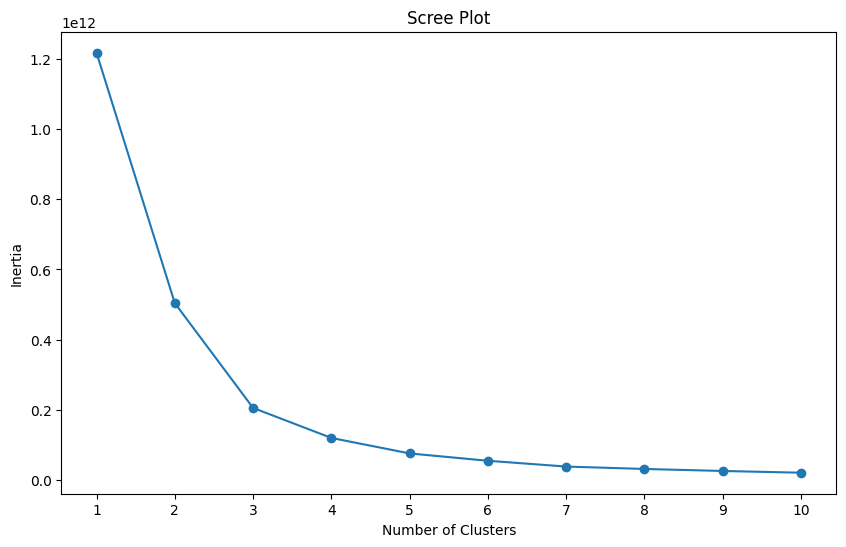

AttributeError: 'numpy.ndarray' object has no attribute 'drop'

In [72]:
# Plot scree plot for real_data
plot_scree(data.drop(columns=['Cluster']), max_clusters=10)

# Plot scree plot for generated_data
plot_scree(generated_data.drop(columns=['Cluster']), max_clusters=10)

In [54]:
# Assuming `real_data` and `generated_data` are pandas DataFrames
real_labels = cluster_data(data)
generated_labels = cluster_data(rounded_df)

In [57]:
from sklearn.metrics import silhouette_score

def analyze_clusters(real_data, generated_data, real_labels, generated_labels):
    # Calculate Silhouette Scores for real and generated data
    silhouette_real = silhouette_score(real_data, real_labels)
    silhouette_generated = silhouette_score(generated_data, generated_labels)

    print(f"Silhouette Score for Real Data: {silhouette_real}")
    print(f"Silhouette Score for Generated Data: {silhouette_generated}")

    # Analyze cluster distribution
    real_cluster_counts = real_data['Cluster'].value_counts().sort_index()
    generated_cluster_counts = generated_data['Cluster'].value_counts().sort_index()

    # Calculate and display relative differences in cluster counts
    cluster_comparison = pd.DataFrame({
        'Real': real_cluster_counts,
        'Generated': generated_cluster_counts,
        'Difference (%)': ((generated_cluster_counts - real_cluster_counts) / real_cluster_counts * 100).round(2)
    })
    print("Cluster Count Comparison:\n", cluster_comparison)

    # Detailed statistical comparison for each cluster
    for cluster in range(max(real_labels) + 1):
        print(f"\n--- Cluster {cluster} ---")
        real_cluster_data = real_data[real_data['Cluster'] == cluster].describe()
        generated_cluster_data = generated_data[generated_data['Cluster'] == cluster].describe()
        
        # Calculate percentage differences for mean values
        comparison = pd.DataFrame({
            'Real Mean': real_cluster_data.loc['mean'],
            'Generated Mean': generated_cluster_data.loc['mean'],
            'Difference (%)': ((generated_cluster_data.loc['mean'] - real_cluster_data.loc['mean']) / real_cluster_data.loc['mean'] * 100).round(2)
        })
        print("Mean Value Comparison:\n", comparison)



In [58]:
analyze_clusters(data, rounded_df, real_labels, generated_labels)

Silhouette Score for Real Data: 0.7551915425929893
Silhouette Score for Generated Data: 0.5539153615268803


KeyError: 'Cluster'

In [50]:
# Save the DataFrame to a CSV file
rounded_df.to_csv('../../data/generated_data.csv', index=False)

# The 'index=False' parameter is used to prevent pandas from writing row indices into the CSV file.

In [38]:
def plot_feature_distributions(real_data, generated_data, feature_names):
    fig, axes = plt.subplots(nrows=len(feature_names), ncols=2, figsize=(12, 2 * len(feature_names)))

    for i, feature_name in enumerate(feature_names):
        # Check if the feature should be treated as categorical
        unique_values_real = real_data[feature_name].nunique()
        unique_values_generated = generated_data[feature_name].nunique()

        if unique_values_real <= 10 and unique_values_generated <= 20:
            # Convert to categorical type if not already
            real_data[feature_name] = pd.Categorical(real_data[feature_name])
            generated_data[feature_name] = pd.Categorical(generated_data[feature_name])

            # Real data bar plot
            ax = axes[i, 0]
            real_data[feature_name].value_counts().sort_index().plot(kind='bar', ax=ax, color='blue', alpha=0.7)
            ax.set_title(f'Real Data - {feature_name}')
            ax.legend([f'Real - {feature_name}'])

            # Generated data bar plot
            ax = axes[i, 1]
            generated_data[feature_name].value_counts().sort_index().plot(kind='bar', ax=ax, color='green', alpha=0.7)
            ax.set_title(f'Generated Data - {feature_name}')
            ax.legend([f'Generated - {feature_name}'])
        
        else:
            # Real data histogram
            ax = axes[i, 0]
            ax.hist(real_data[feature_name], bins=30, color='blue', alpha=0.7)
            ax.set_title(f'Real Data - {feature_name}')
            ax.legend([f'Real - {feature_name}'])

            # Generated data histogram
            ax = axes[i, 1]
            ax.hist(generated_data[feature_name], bins=30, color='green', alpha=0.7)
            ax.set_title(f'Generated Data - {feature_name}')
            ax.legend([f'Generated - {feature_name}'])

    plt.tight_layout()
    plt.show()

In [44]:
data.columns

Index(['sex', 'age_sim', 'lv_educ', 'empl_stat', 'marit_stat', 'house_memb',
       'chil_u_18_y', 'nation', 'religion', 'soc_econ_stat', 'prof_ind',
       'prof_stat', 'count_house', 'own_field', 'num_car_house',
       'own_rent_house', 'edu', 'temperam', 'ind_risk_sim', 'invest_exp_sim',
       'shares', 'corp_oblig', 'oth', 'inv_fund', 'cash', 'crypto', 'gov_bond',
       'deposits', 'income_sim', 'pers_exp_sim', 'house_exp_sim', 'taxes_sim',
       'transp_telecom_sim', 'hobby_sim', 'banking', 'bk_oprat', 'bk_dc',
       'bk_cc', 'bk_acc', 'ins_prop', 'ins_life', 'ins_casco', 'health_ins',
       'overdraft', 'cons_cred', 'mortgage', 'car_leas', 'pens_ins'],
      dtype='object')

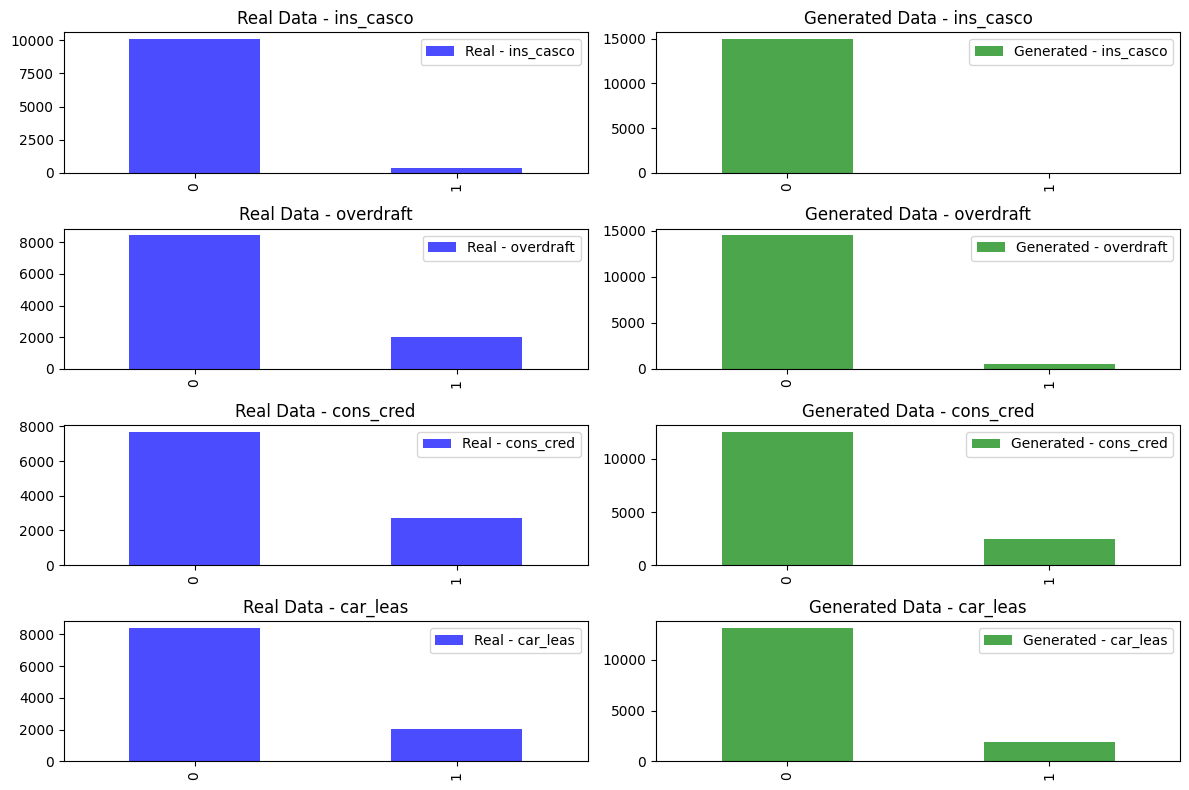

In [60]:
# Example usage, assuming data dimensions are compatible and feature_names are provided
feature_names_to_plot = [
    #'age_sim', 'lv_educ', 'empl_stat', 'marit_stat', 'house_memb']#,
    #'chil_u_18_y', 'religion', 'soc_econ_stat', 'prof_ind', 'prof_stat']#, 
    #'count_house', 'own_field']#,
    #'num_car_house', 'own_rent_house']#, 'edu', 
    #'temperam', 'ind_risk_sim']#, 
    #'invest_exp_sim','shares']#, 
    #'gov_bond', 'deposits']#,
    #'income_sim', 'pers_exp_sim', 'house_exp_sim']#,
    #'taxes_sim','transp_telecom_sim', 'hobby_sim']#, 'banking',
    #'bk_oprat', 'bk_dc','bk_cc', 'bk_acc']#, 
    'ins_casco', 'overdraft', 'cons_cred', 'car_leas']  # Specify feature names you are interested in
plot_feature_distributions(
    real_data=data, 
    generated_data=rounded_df, 
    feature_names=feature_names_to_plot
)

In [40]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# Normalize the datasets
scaler = StandardScaler()
data1_normalized = scaler.fit_transform(data)
data2_normalized = scaler.fit_transform(generated_data)

# Compute the mean vector for each dataset
mean_vector1 = np.mean(data1_normalized, axis=0)
mean_vector2 = np.mean(data2_normalized, axis=0)

# Compute cosine similarity
cosine_sim = cosine_similarity([mean_vector1], [mean_vector2])

print(f"Cosine similarity between the two datasets: {cosine_sim[0][0]}")


Cosine similarity between the two datasets: -3.414394142485104e-16


In [33]:
data = data.drop(columns=['Cluster'])

## Summary

The GAN produces tabular synthetic data by learning the full joint distribution of the input dataset — including complex non-linear relationships between features. Key validation checks:

| Check | Method |
|---|---|
| Mean fidelity | Cosine similarity of mean vectors |
| Cluster structure | K-means + silhouette score |
| Marginal distributions | Feature distribution plots |

**Pre-trained models** are stored in `../../models/generator.tf` and `../../models/discriminator.tf` and can be reloaded without retraining.

**Related publications:**
- Marchev, V., Marchev, A. (2025). *Methodological Considerations for Anonymizing Tabular Data Using Generative Adversarial Networks.*
- Marchev, V., Marchev, A., Piryankova, M. et al. (2023). *Synthesizing an anonymized multidimensional dataset.* VSIM vol. 19, no. 1.